# 🎬 Netflix Prize — Personalized Recommendation System

This notebook walks through the **entire pipeline** end-to-end, reusing the
project's pure-Python `recsys` package (so the notebook and the offline
scripts/CLI stay perfectly consistent):

1. Load / generate the data
2. Exploratory Data Analysis (EDA)
3. Train/test split
4. Train three models — **bias baseline**, **item-based CF**, **matrix factorization**
5. Evaluate with **RMSE + MAP@10** (+ Precision/Recall/NDCG/HitRate/Coverage)
6. Generate **Top-K recommendations** with explanations
7. Explore similar movies + conclusions

> The core runs on the **Python standard library alone** (no numpy/pandas needed).
> `matplotlib`/`pandas` are used *only if present* — otherwise the notebook
> falls back to the project's pre-rendered SVG charts and HTML tables.

## 0. Environment & imports

In [25]:
import os, sys

# Make the local `recsys` package importable (notebook lives in notebooks/).
SRC = os.path.abspath(os.path.join("..", "src"))
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from recsys.config import load_config
from recsys.data.dataset import Dataset, train_test_split
from recsys.data.make_sample import generate
from recsys.eda.analyze import run_eda
from recsys.cli import build_model
from recsys.evaluation.evaluate import evaluate_model
from recsys.recommend.recommender import RecommendationService

cfg = load_config()
ROOT = cfg["_repo_root"]
rp = lambda rel: os.path.join(ROOT, rel)
print("repo root:", ROOT)
print("seed     :", cfg["seed"])

repo root: /Users/abhaysingh/Downloads/CULT-AI-ML-feature-netflix-recommender-2
seed     : 42


## 1. Load / generate the data

The repo ships a seeded synthetic Netflix-like sample so this runs out of the box. To use the **real** Netflix Prize data instead, run `python scripts/preprocess.py ...` first (see the README) — the rest of the notebook is unchanged.

In [26]:
ratings_path = rp(cfg["paths"]["ratings_file"])
movies_path = rp(cfg["paths"]["movies_file"])

if not os.path.exists(ratings_path):
    sc = cfg["sample"]
    data = generate(
        n_users=sc["n_users"], n_movies=sc["n_movies"],
        target_ratings=sc["target_ratings"], n_archetypes=sc["n_latent_archetypes"],
        start_year=sc["start_year"], end_year=sc["end_year"], seed=cfg["seed"],
    )
    data.to_csv(ratings_path, movies_path)
    print("generated synthetic sample")

data = Dataset.from_csv(ratings_path, movies_path)
print(f"ratings : {len(data):,}")
print(f"users   : {data.n_users:,}")
print(f"movies  : {data.n_items:,}")
print(f"sparsity: {data.sparsity()*100:.2f}%")
print(f"mean    : {data.global_mean():.3f}")

ratings : 90,065
users   : 2,000
movies  : 800
sparsity: 94.37%
mean    : 4.123


## 2. Exploratory Data Analysis

`run_eda` computes the statistics, writes a Markdown report + CSVs + JSON to `reports/`, and renders SVG charts to `reports/figures/`. It returns the stats dict we use below.

In [27]:
stats = run_eda(data, rp(cfg["paths"]["reports_dir"]), rp(cfg["paths"]["figures_dir"]))


==================== EDA SUMMARY ====================
  ratings        : 90,065
  users          : 2,000
  movies         : 800
  sparsity       : 94.3709%  (density 5.6291%)
  global mean    : 4.1234
  ratings/user   : mean 45.0  median 31  max 604
  ratings/movie  : mean 112.6  median 82  max 617
  most popular   : The Electric Echo [Documentary] (1988)


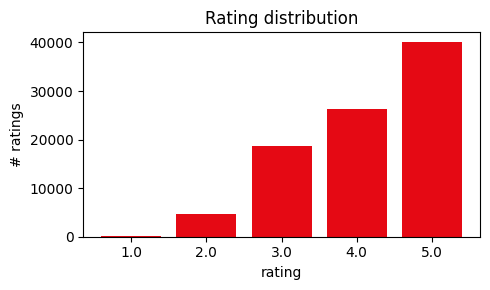

In [28]:
# --- Rating distribution: matplotlib if available, else the pre-rendered SVG ---
hist = stats["rating_histogram"]
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5, 3))
    plt.bar([str(k) for k in hist], list(hist.values()), color="#E50914")
    plt.title("Rating distribution"); plt.xlabel("rating"); plt.ylabel("# ratings")
    plt.tight_layout(); plt.show()
except ImportError:
    from IPython.display import SVG, display
    print("matplotlib not installed -> showing pre-rendered SVG chart")
    display(SVG(filename=rp(os.path.join(cfg["paths"]["figures_dir"], "rating_distribution.svg"))))

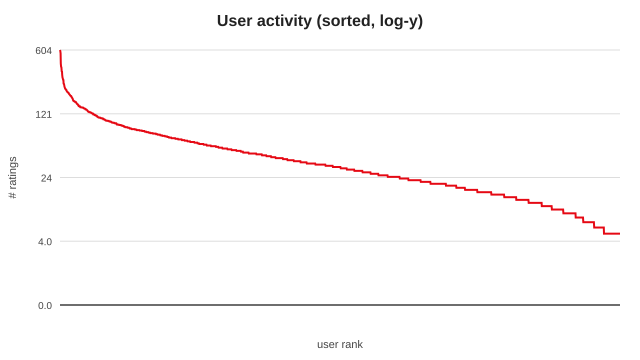

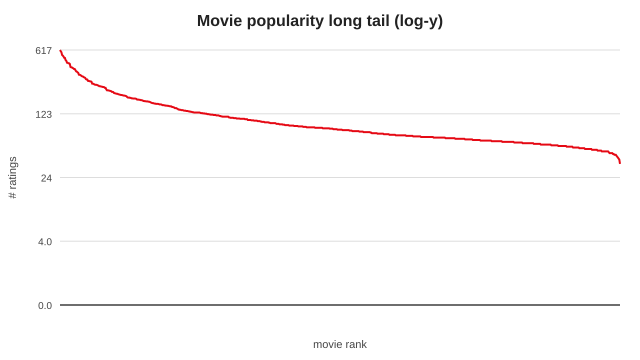

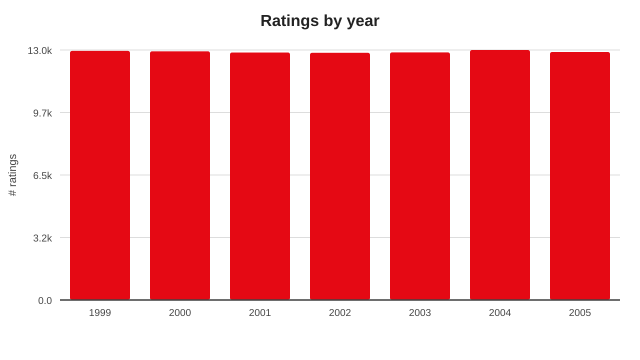

In [29]:
# Long-tail charts (always shown from the pre-rendered SVGs).
from IPython.display import SVG, display
for name in ["user_activity.svg", "item_popularity.svg", "ratings_by_year.svg"]:
    p = rp(os.path.join(cfg["paths"]["figures_dir"], name))
    if os.path.exists(p):
        display(SVG(filename=p))

In [30]:
# Most-rated movies
print("Most-rated movies:")
for m in stats["most_popular"][:10]:
    print(f"  {m['n_ratings']:>5}  {m['title']}")

Most-rated movies:
    617  The Electric Echo [Documentary] (1988)
    599  The Radiant Tempest: Legacy [Action] (2004)
    584  The Wild Mirage [Mystery] (2001)
    544  The Burning Echo 2 [Sci-Fi] (1993)
    536  The Last Dream [Drama] (1985)
    523  The Burning Empire [Documentary] (1982)
    507  The Radiant Tempest 2 [Comedy] (1982)
    505  The Broken Dream [Romance] (1992)
    478  The Electric Tempest 4 [Mystery] (1978)
    470  The Crimson Harbor [Sci-Fi] (1985)


### EDA takeaways
- **High sparsity (94%+)** -> neighbourhood models need shrinkage; latent-factor models need regularization.
- **Long-tail popularity** -> guard against popularity bias (we track **coverage**).
- **Heavy-tailed user activity** -> evaluate **per user** so power users don't skew metrics.
- **Positive rating bias** -> model explicit user/item biases before latent factors.

## 3. Train/test split

We hold out ratings **per user** so every test user is seen during training (no user cold-start while scoring) — the standard protocol for measuring Top-K quality.

In [31]:
sp = cfg["split"]
train, test = train_test_split(
    data, test_fraction=sp["test_fraction"], strategy=sp["strategy"],
    min_train_ratings=sp["min_train_ratings"], min_test_ratings=sp["min_test_ratings"],
    seed=cfg["seed"],
)
print(f"train: {len(train):,}   test: {len(test):,}   strategy: {sp['strategy']}")

train: 72,058   test: 18,007   strategy: random_per_user


## 4. Train the three models

- **baseline** — `mu + b_u + b_i` (regularized biases)
- **item_cf** — item-based CF, adjusted cosine + shrinkage
- **mf** — matrix factorization (Funk-SVD with biases, SGD)

In [32]:
models = {}
for name in ["baseline", "item_cf", "mf"]:
    m = build_model(name, cfg, verbose=(name == "mf"))
    m.fit(train)
    models[name] = m
    print(f"fitted: {name}")

fitted: baseline
fitted: item_cf
    [mf] epoch  1/30 lr=0.0120 train_rmse=0.8932
    [mf] epoch  2/30 lr=0.0118 train_rmse=0.8643
    [mf] epoch  3/30 lr=0.0116 train_rmse=0.8552
    [mf] epoch  4/30 lr=0.0115 train_rmse=0.8500
    [mf] epoch  5/30 lr=0.0113 train_rmse=0.8455
    [mf] epoch  6/30 lr=0.0111 train_rmse=0.8405
    [mf] epoch  7/30 lr=0.0110 train_rmse=0.8336
    [mf] epoch  8/30 lr=0.0108 train_rmse=0.8231
    [mf] epoch  9/30 lr=0.0106 train_rmse=0.8076
    [mf] epoch 10/30 lr=0.0105 train_rmse=0.7858
    [mf] epoch 11/30 lr=0.0103 train_rmse=0.7584
    [mf] epoch 12/30 lr=0.0102 train_rmse=0.7273
    [mf] epoch 13/30 lr=0.0100 train_rmse=0.6955
    [mf] epoch 14/30 lr=0.0099 train_rmse=0.6656
    [mf] epoch 15/30 lr=0.0097 train_rmse=0.6385
    [mf] epoch 16/30 lr=0.0096 train_rmse=0.6146
    [mf] epoch 17/30 lr=0.0094 train_rmse=0.5939
    [mf] epoch 18/30 lr=0.0093 train_rmse=0.5758
    [mf] epoch 19/30 lr=0.0091 train_rmse=0.5602
    [mf] epoch 20/30 lr=0.0090 train

## 5. Evaluation — RMSE + MAP@10 (+ extras)

Relevance for MAP@10: a held-out movie counts as relevant if its actual rating >= 3.5.

In [33]:
ev = cfg["evaluation"]
results = [
    evaluate_model(models[n], train, test, k=ev["k"],
                   relevance_threshold=ev["relevance_threshold"],
                   max_eval_users=ev["max_eval_users"], seed=cfg["seed"])
    for n in ["baseline", "item_cf", "mf"]
]
rows = [r.as_dict() for r in results]
k = ev["k"]
cols = ["model", "rmse", "mae", f"map@{k}", f"precision@{k}", f"recall@{k}",
        f"ndcg@{k}", f"hit_rate@{k}", "coverage"]

try:
    import pandas as pd
    df = pd.DataFrame(rows)[cols].set_index("model")
    display(df.round(4))
except ImportError:
    from IPython.display import HTML, display
    html = "<table><tr>" + "".join(f"<th>{c}</th>" for c in cols) + "</tr>"
    for r in rows:
        html += "<tr>" + "".join(
            (f"<td>{r[c]:.4f}</td>" if isinstance(r[c], float) else f"<td>{r[c]}</td>")
            for c in cols) + "</tr>"
    html += "</table>"
    display(HTML(html))

,rmse,mae,map@10,precision@10,recall@10,ndcg@10,hit_rate@10,coverage
model,,,,,,,,
baseline,0.8784,0.7403,0.0071,0.0113,0.0148,0.0166,0.1013,0.0312
item_cf,0.6638,0.4821,0.0248,0.0467,0.0504,0.0532,0.2693,0.8700
mf,0.6214,0.4806,0.0508,0.0851,0.0952,0.1022,0.4347,0.6025


### Discussion (accuracy vs. ranking)
- **Matrix factorization** typically wins on **both RMSE and MAP@10** — latent factors capture personalized taste.
- **Item-based CF** trades a little ranking quality for the **highest coverage** (recommends a wider slice of the catalogue -> better discovery).
- The **bias baseline** is a cheap, strong RMSE reference but is **non-personalized**, so it ranks poorly.
- Small RMSE gaps can hide large ranking differences — which is exactly why we report **MAP@10**, not just RMSE.

## 6. Top-K recommendations + explanations

In [34]:
svc = RecommendationService(models["mf"], train)
user = train.users[0]

print(f"User {user} — taste profile (top training ratings):")
for p in svc.user_profile(user, top_n=6):
    print(f"   {int(p['rating'])}*  {p['title']}")

print(f"\nTop-{ev['k']} recommendations (matrix factorization):")
for rec in svc.top_k(user, k=ev["k"]):
    print(f"  {rec['rank']:>2}. [{rec['score']:.2f}] {rec['title']}")
    print(f"        -> {rec['explanation']}")

User 1 — taste profile (top training ratings):
   5*  The Restless Dream [Comedy] (1990)
   5*  The Burning Sentinel [Comedy] (1999)
   5*  The Burning Reckoning 2: Promise [Comedy] (1987)
   5*  The Electric Echo [Comedy] (1982)
   5*  The Hollow Awakening: Vendetta [Comedy] (1974)
   5*  The Broken Horizon [Comedy] (1989)

Top-10 recommendations (matrix factorization):
   1. [4.90] The Lonely Horizon: Promise [Mystery] (1995)
        -> Predicted to match your taste (estimated rating 4.90/5)
   2. [4.80] The Lonely Kingdom [Comedy] (1980)
        -> Predicted to match your taste (estimated rating 4.80/5)
   3. [4.79] The Burning Tempest [Documentary] (1993)
        -> Predicted to match your taste (estimated rating 4.79/5)
   4. [4.78] The Hidden Ascent [Comedy] (1978)
        -> Predicted to match your taste (estimated rating 4.78/5)
   5. [4.78] The Hidden Echo [Comedy] (1985)
        -> Predicted to match your taste (estimated rating 4.78/5)
   6. [4.76] The Broken Voyage [Comedy]

In [35]:
# Explainable recommendations are richer for the neighbourhood model:
svc_cf = RecommendationService(models["item_cf"], train)
for rec in svc_cf.top_k(user, k=5):
    print(f"[{rec['score']:.2f}] {rec['title']}")
    print(f"     {rec['explanation']}\n")

[5.00] The Lonely Kingdom [Comedy] (1980)
     Because you rated highly: The Electric Echo [Comedy] (1982), The Radiant Tempest 2 [Comedy] (1982), The Restless Dream [Comedy] (1990)

[5.00] The Lonely Ascent [Comedy] (1983)
     Because you rated highly: The Radiant Tempest 2 [Comedy] (1982), The Hollow Awakening: Vendetta [Comedy] (1974), The Restless Dream [Comedy] (1990)

[5.00] The Restless Horizon: Paradox [Comedy] (1982)
     Because you rated highly: The Radiant Tempest 2 [Comedy] (1982), The Hollow Awakening: Vendetta [Comedy] (1974), The Electric Echo [Comedy] (1982)

[5.00] The Eternal Ascent [Mystery] (1992)
     Predicted to match your taste (estimated rating 4.18/5)

[5.00] The Broken Voyage [Comedy] (1992)
     Because you rated highly: The Radiant Tempest 2 [Comedy] (1982), The Burning Reckoning 2: Promise [Comedy] (1987), The Hollow Awakening: Vendetta [Comedy] (1974)



## 7. Explore similar movies

Item-based CF gives us item-item similarities for free, so we can build a "more like this" view.

In [36]:
seed_movie = stats["most_popular"][0]["movie_id"]
print("Movies similar to:", train.movie_title(seed_movie), "\n")
for s in svc_cf.similar_items(seed_movie, k=10):
    print(f"  sim={s['similarity']:.3f}   {s['title']}")

Movies similar to: The Electric Echo [Documentary] (1988) 

  sim=0.199   The Secret Vendetta [Documentary] (1997)
  sim=0.198   The Burning Empire [Documentary] (1982)
  sim=0.197   The Golden Echo [Documentary] (1978)
  sim=0.192   The Midnight Tempest: Awakening [Documentary] (1991)
  sim=0.192   The Silent Promise [Documentary] (1990)
  sim=0.177   The Midnight Horizon: Mirage [Documentary] (1976)
  sim=0.172   The Crimson Mirage [Documentary] (2000)
  sim=0.163   The Hidden Kingdom [Documentary] (1993)
  sim=0.162   The Eternal Covenant [Documentary] (1985)
  sim=0.157   The Restless Sentinel [Documentary] (1978)


## 8. Conclusions & future work

**What we built.** A reproducible recommendation pipeline on the Netflix Prize data:
EDA -> three models -> RMSE + MAP@10 evaluation -> explainable Top-K recommendations.

**Key insights.**
- Model biases first (cheap, strong RMSE), then add latent factors for ranking — they are complementary.
- Optimise and report **ranking metrics (MAP@10)**, not only RMSE.
- Watch **coverage**: the highest-MAP model isn't always best for catalogue-wide discovery.

**Future work.** Cold-start back-off, a hybrid (MF + content metadata + CF ensemble),
SVD++/temporal dynamics, a ranking loss (BPR/WARP), and numpy/ALS to scale to the full 100M ratings.

Reproduce everything from the shell with `python scripts/run_all.py`.